# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(200)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
...,...,...,...,...,...,...,...
195,850,465,49,2,2,1,1
196,850,580,50,2,2,1,1
197,850,881,50,2,2,1,1
198,850,513,45,1,1,0,0


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [10]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [12]:
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [ ]:
# o DataFrame está completo e sem valores faltantes.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [13]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


Text(0.5, 1.0, 'Número de Quartos - Outliers')

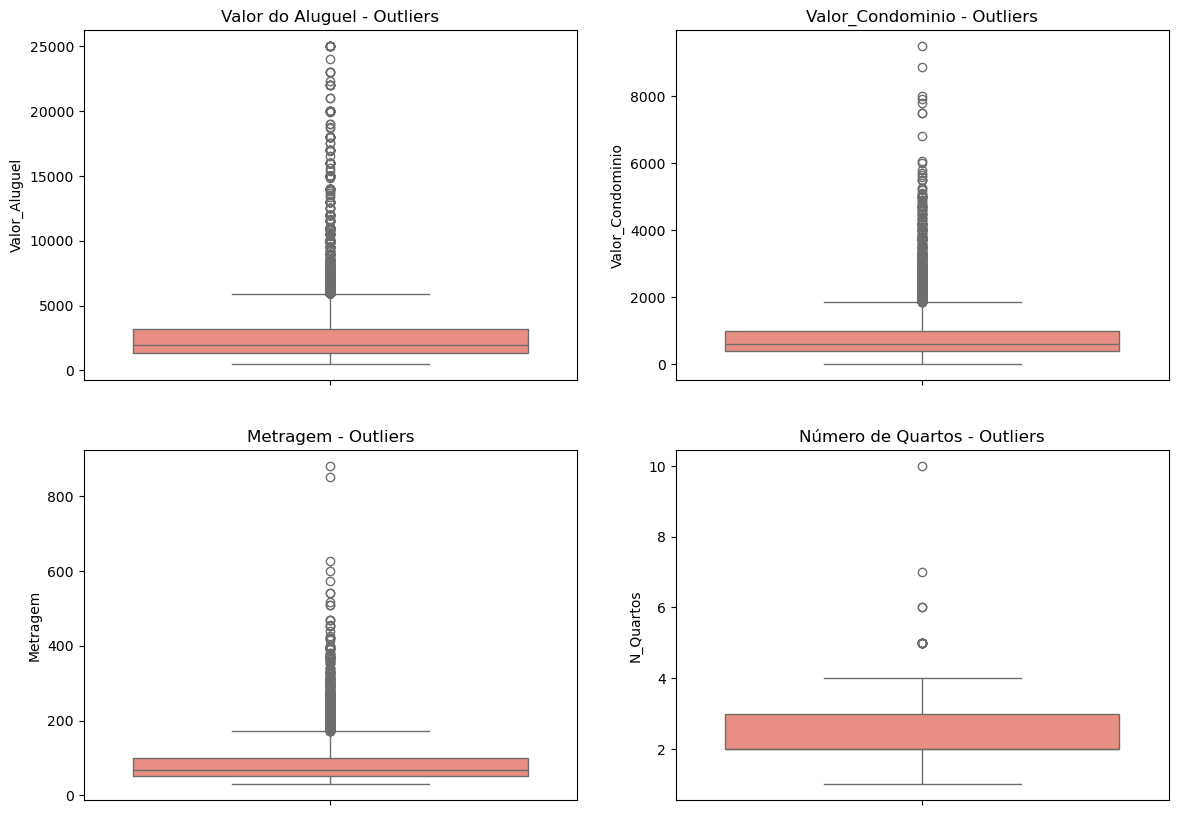

In [32]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
                         
sns.boxplot(data=df, y='Valor_Aluguel', ax=axes[0,0], color='salmon')
axes[0,0].set_title('Valor do Aluguel - Outliers')

sns.boxplot(data=df, y='Valor_Condominio', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Valor_Condominio - Outliers')

sns.boxplot(data=df, y='Metragem', ax=axes[1,0], color='salmon')
axes[1,0].set_title('Metragem - Outliers')

sns.boxplot(data=df, y='N_Quartos', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Número de Quartos - Outliers')                 

In [37]:
df['Valor_Aluguel_Log'] = np.log1p(df['Valor_Aluguel'])
df['Valor_Condominio_Log'] = np.log1p(df['Valor_Condominio'])
df['Metragem_Log'] = np.log1p(df['Metragem'])

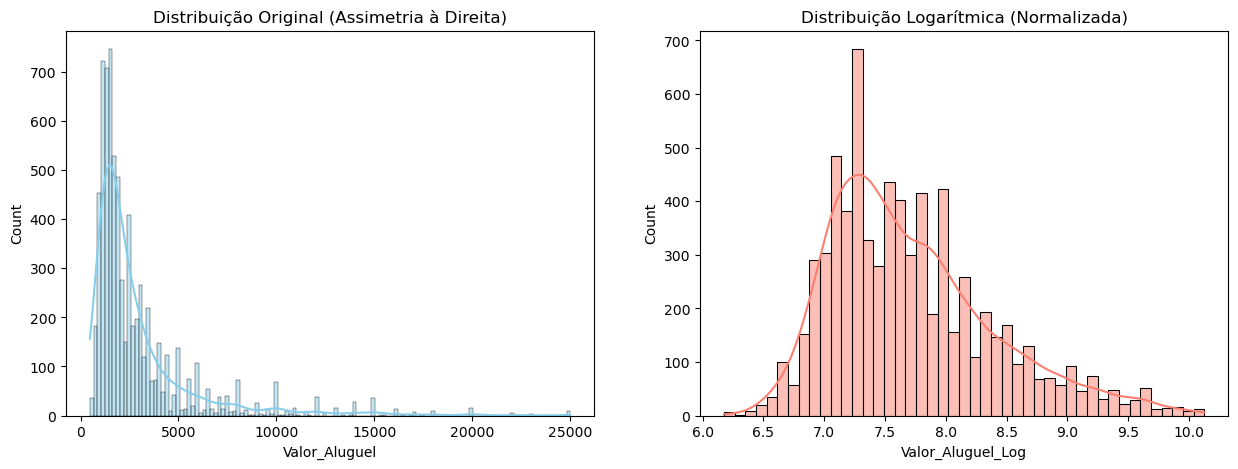

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Valor_Aluguel'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Original (Assimetria à Direita)')

sns.histplot(df['Valor_Aluguel_Log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição Logarítmica (Normalizada)')

plt.show()

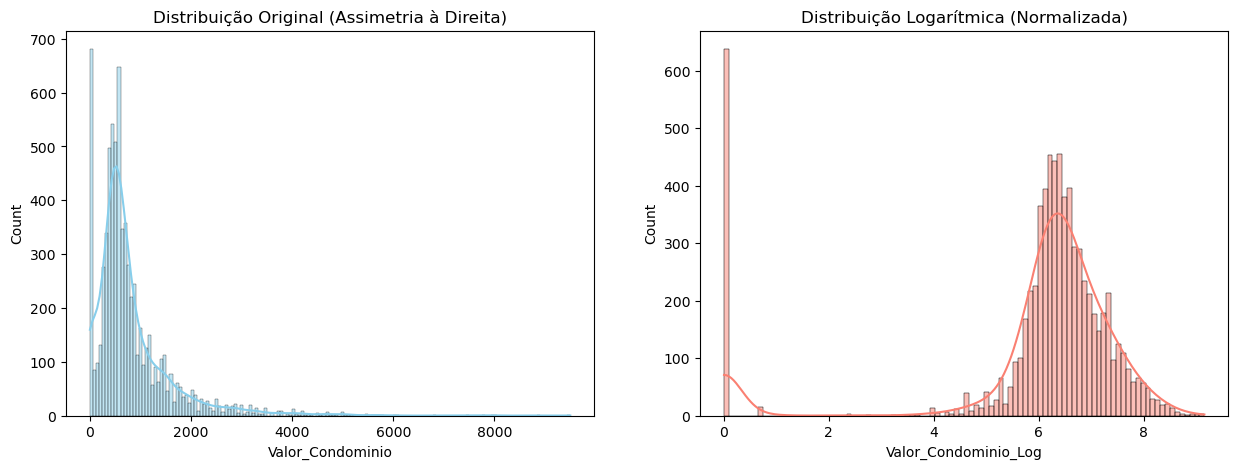

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Valor_Condominio'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Original (Assimetria à Direita)')

sns.histplot(df['Valor_Condominio_Log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição Logarítmica (Normalizada)')

plt.show()

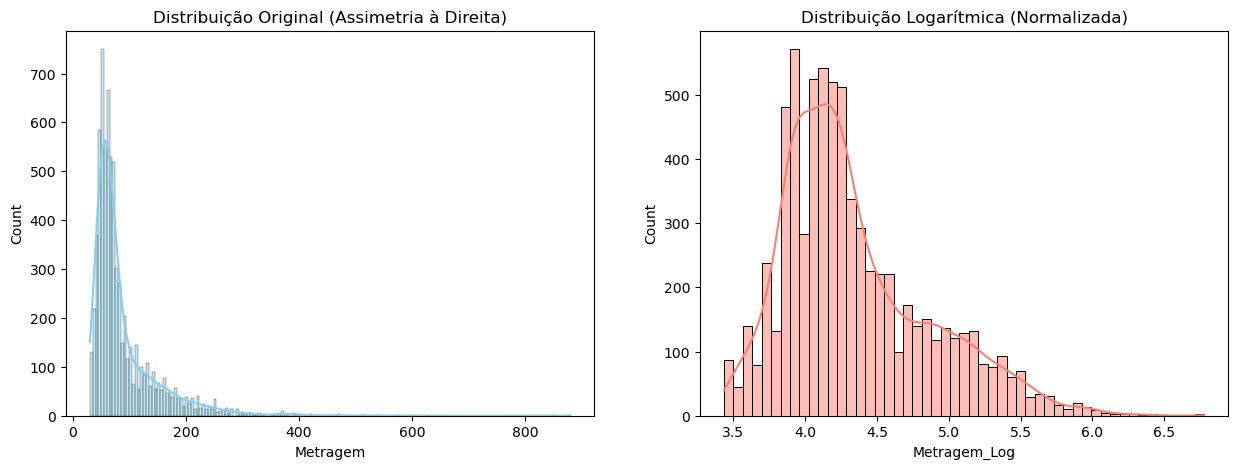

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Metragem'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Original (Assimetria à Direita)')

sns.histplot(df['Metragem_Log'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição Logarítmica (Normalizada)')

plt.show()

In [ ]:
'''
Normalizei a assimetria dos dados, estabilizando a variância 
e reduzindo o impacto desproporcional de valores extremos 
(outliers) para converter as variações absolutas em proporções relativas
'''

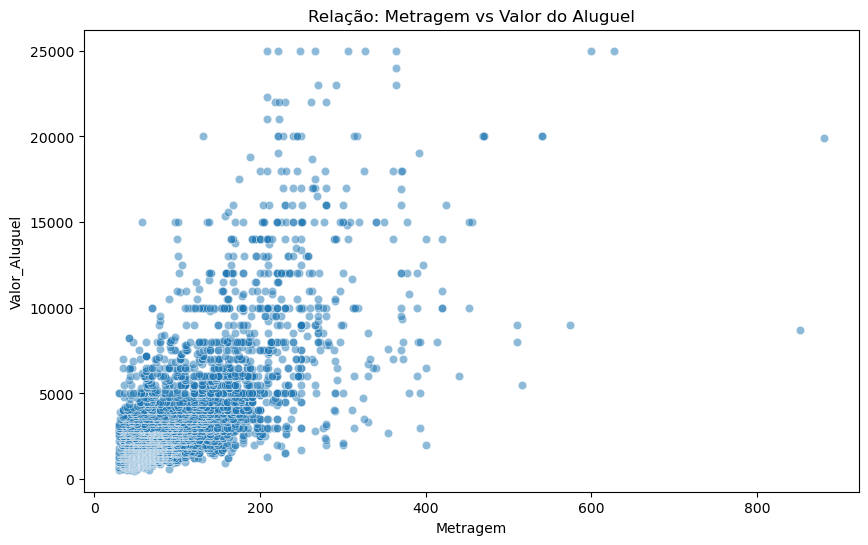

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Metragem', y='Valor_Aluguel', alpha=0.5)
plt.title('Relação: Metragem vs Valor do Aluguel')
plt.show()

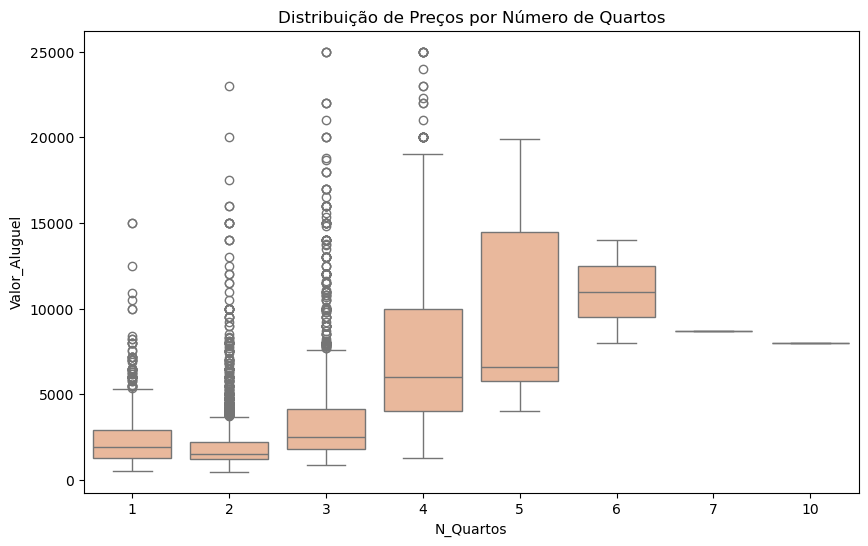

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='N_Quartos', y='Valor_Aluguel', color=sns.color_palette('rocket')[5])
plt.title('Distribuição de Preços por Número de Quartos')
plt.show()

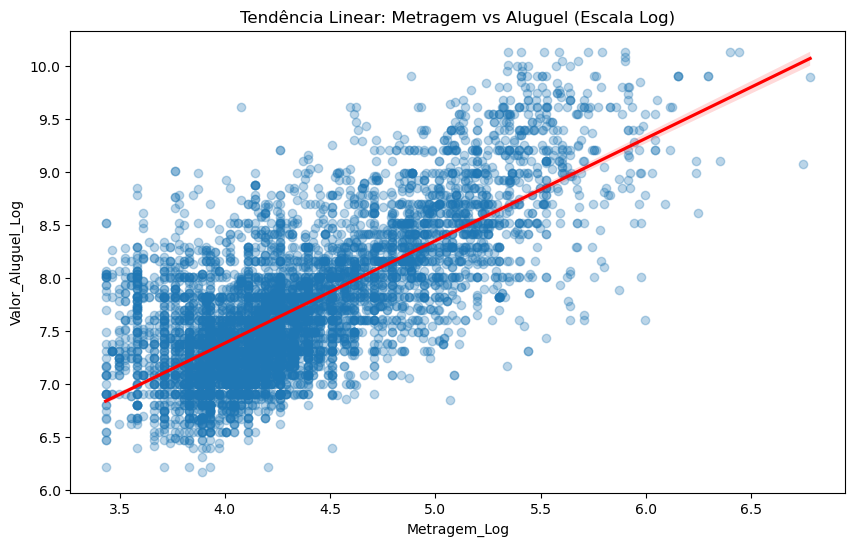

In [47]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Metragem_Log', y='Valor_Aluguel_Log', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tendência Linear: Metragem vs Aluguel (Escala Log)')
plt.show()

In [49]:
# Média por grupo
df.groupby('Metragem')['Valor_Aluguel'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
Metragem,,,
30,1819.77,1295.0,1144.89
31,1956.19,1500.0,925.14
32,1610.77,1400.0,561.87
33,2204.20,2000.0,820.05
34,1929.50,1625.0,902.72
...,...,...,...
574,9000.00,9000.0,NaN
600,25000.00,25000.0,NaN
627,25000.00,25000.0,NaN


In [ ]:
'''
A área (Metragem) é o principal driver de custo, mas sua influência diminui em imóveis de altíssimo valor.
'''

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




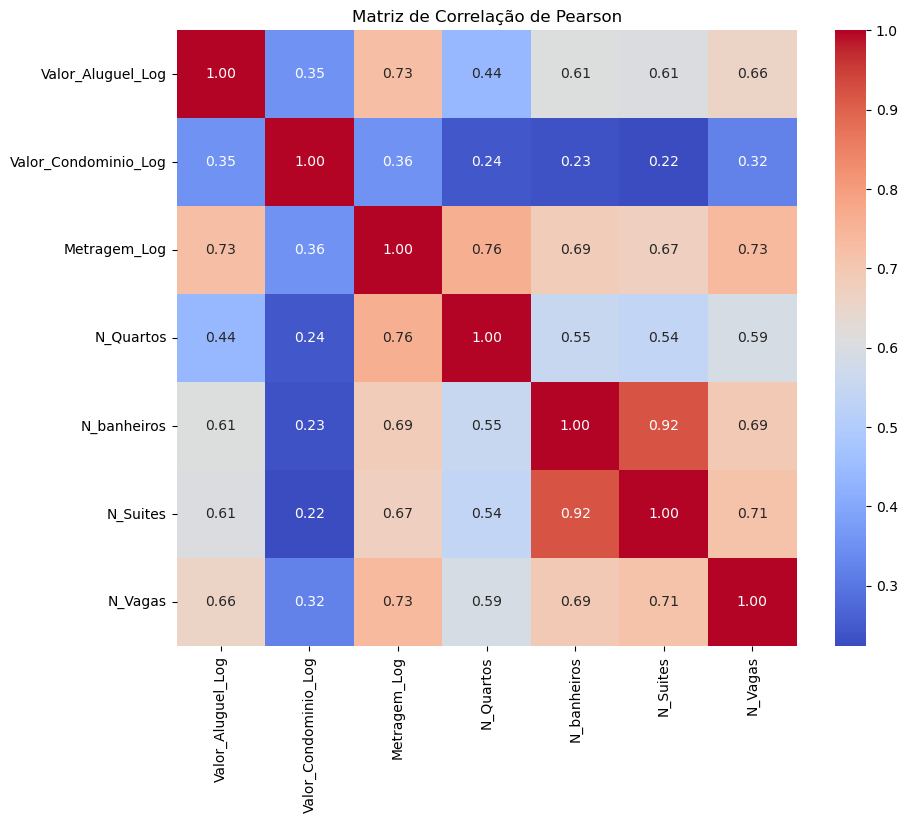

In [54]:
plt.figure(figsize=(10, 8))
corr = df[['Valor_Aluguel_Log', 'Valor_Condominio_Log', 'Metragem_Log',	'N_Quartos', 'N_banheiros',	'N_Suites',	'N_Vagas']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação de Pearson')
plt.show()

In [ ]:
'''
Número de suites e número de banheiros possui a correlação mais forte do df. E o que menos tem influencia,
ou melhor, em relação as demais variáveis é o valor do condomínio.
'''


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [56]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 5042 amostras
Teste: 2161 amostras


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [60]:
X_train_simples = X_train[['Metragem']]
X_test_simples = X_test[['Metragem']]

In [61]:
modelo_simples = LinearRegression()
modelo_simples.fit(X_train_simples, y_train)

Intercepto (b0): -90.46364573389337
Coeficiente de Metragem (b1): 34.48374826688315


B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [62]:
print(f"Intercepto: {modelo_simples.intercept_}")
print(f"Coeficiente de Metragem: {modelo_simples.coef_[0]}")

Intercepto (b0): -90.46364573389337
Coeficiente de Metragem (b1): 34.48374826688315


In [ ]:
# y = -90.46 + (34.48*Metragem)

Nossa equação seria:  

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [63]:
r2_treino = modelo_simples.score(X_train_simples, y_train)

print(f"R² (Treino): {r2_treino:.4f}")

R² (Treino): 0.5175


In [ ]:
'''
O resultado mostra que o modelo de Regressão Linear Simples
é insuficiente. É necessário evoluir para uma Regressão Linear Múltipla 
(utilizando todas as variáveis de X) para capturar a complexidade do
mercado e elevar a precisão do modelo.
'''

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

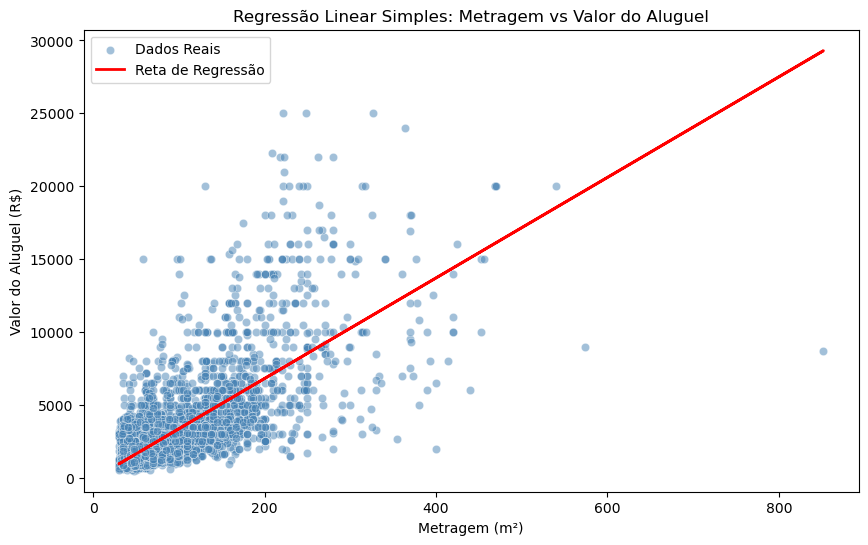

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=X_train_simples['Metragem'], y=y_train, color='steelblue', alpha=0.5, label='Dados Reais')

y_pred_treino = modelo_simples.predict(X_train_simples)
plt.plot(X_train_simples['Metragem'], y_pred_treino, color='red', linewidth=2, label='Reta de Regressão')

plt.title('Regressão Linear Simples: Metragem vs Valor do Aluguel')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')
plt.legend()
plt.show()

In [ ]:
'''
Observa-se que, para metragens menores, os pontos estão
mais próximos da reta. À medida que a metragem aumenta,
a dispersão dos pontos cresce drasticamente. Isso indica
que a área sozinha é uma boa preditora para imóveis
pequenos, mas insuficiente para imóveis grandes, onde 
o acabamento e a localização pesam mais.
'''

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [65]:
X_test = X_test[['Metragem']]  
y_pred_test = modelo_simples.predict(X_test_simples)

In [69]:
r2_teste = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"R² (Teste): {r2_teste:.4f}")
print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): R$ {rmse:.2f}")

R² (Teste): 0.5668
Erro Médio Absoluto (MAE): R$ 1159.49
Raiz do Erro Quadrático Médio (RMSE): R$ 2027.38


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

'''
Um ponto positivo é que o R2 do teste foi ligeiramente superior
ao de treino. Isso demonstra que o modelo não "decorou" os dados
(não houve overfitting), mantendo a mesma consistência ao 
lidar com informações inéditas. O modelo é estável, porém pouco preciso.
'''

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [78]:
X = df.drop('Valor_Aluguel', axis=1)
y = df['Valor_Aluguel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (5042, 9)
Shape X_test: (2161, 9)


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [79]:
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train, y_train)
coeficientes = pd.DataFrame(modelo_multiplo.coef_, X.columns, columns=['Coeficiente'])
intercepto = modelo_multiplo.intercept_

print(f"Intercepto (b0): {intercepto:.2f}")
print("\nCoeficientes das Variáveis:")
print(coeficientes)

Intercepto (b0): -16344.36

Coeficientes das Variáveis:
                      Coeficiente
Valor_Condominio         0.358199
Metragem                18.097948
N_Quartos              -22.186091
N_banheiros            -56.899230
N_Suites               221.920342
N_Vagas                 51.337260
Valor_Aluguel_Log     3383.387298
Valor_Condominio_Log  -102.403767
Metragem_Log         -1893.273667


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [80]:
r2_treino_multiplo = modelo_multiplo.score(X_train, y_train)
print(f"R² (Treino Multiplo): {r2_treino_multiplo:.4f}")

R² (Treino Multiplo): 0.8409


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [81]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_test_multiplo = modelo_multiplo.predict(X_test)

r2_teste_multiplo = r2_score(y_test, y_pred_test_multiplo)

mae_multiplo = mean_absolute_error(y_test, y_pred_test_multiplo)
rmse_multiplo = np.sqrt(mean_squared_error(y_test, y_pred_test_multiplo))

print(f"R² (Teste Múltiplo): {r2_teste_multiplo:.4f}")
print(f"MAE (Múltiplo): R$ {mae_multiplo:.2f}")
print(f"RMSE (Múltiplo): R$ {rmse_multiplo:.2f}")

R² (Teste Múltiplo): 0.8430
MAE (Múltiplo): R$ 736.65
RMSE (Múltiplo): R$ 1220.64


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

'''
O modelo múltiplo corrigiu o subajuste (underfitting) do modelo simples.
A inclusão de variáveis contextuais permitiu ao algoritmo diferenciar, 
por exemplo, um imóvel pequeno de alto padrão 
(com condomínio caro e muitas vagas) de um imóvel de mesma metragem 
porém simples, algo que a regressão simples era 
matematicamente incapaz de discernir.
'''